# Suivi longitudinal LUMIERE — preuve de concept (projet RANO-Auto)

But : verifier qu'on sait charger le suivi de 5 patients dans le temps a partir du
dataset LUMIERE, sans telecharger les 32 Go. On va chercher, pour chaque patient et
chaque examen, le masque de segmentation HD-GLIO deja fourni dans le dataset, on en
deduit le volume tumoral rehaussant (le marqueur cle de RANO), et on trace la
trajectoire dans le temps avec la cotation RANO experte en regard.

Donnees :
- CSV des cotations RANO expertes (deja telecharge dans `data/`)
- masques de segmentation tires a la demande du zip distant via `remotezip`
  (range requests : on ne lit que les octets utiles)

Label HD-GLIO : 2 = tumeur rehaussante (marqueur RANO), 1 = non rehaussant / oedeme.
Verifie via les volumes nommes DeepBraTumIA de LUMIERE (Enhancing_Core == label 2).

In [1]:
import os, re, json, collections
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from remotezip import RemoteZip

ZIP_URL = "https://ndownloader.figshare.com/files/38249697"  # LUMIERE Imaging-v202211.zip (32 Go)
DATA = "data"
CACHE = os.path.join(DATA, "seg_cache")
os.makedirs(CACHE, exist_ok=True)

N_PATIENTS = 5
SEG_REL = "HD-GLIO-AUTO-segmentation/registered/segmentation.nii.gz"  # masque dans un espace commun

In [2]:
rano = pd.read_csv(os.path.join(DATA, "LUMIERE-ExpertRating.csv"))
rano = rano.rename(columns={rano.columns[4]: "RANO", rano.columns[5]: "rationale"})
rano = rano[["Patient", "Date", "RANO", "rationale"]]
print(rano.shape)
rano.head()

(616, 4)


,Patient,Date,RANO,rationale
0,Patient-001,week-000-1,Pre-Op,NaN
1,Patient-001,week-000-2,Post-Op,CRET
2,Patient-001,week-044,SD,NaN
3,Patient-001,week-056,PD,"Target L.: 1 12mm x 13mm, new non-target L."
4,Patient-002,week-000,Pre-Op,NaN


In [3]:
# index des segmentations disponibles dans le zip (lecture de l'index seul, mis en cache)
NAMELIST_CACHE = os.path.join(DATA, "namelist.json")
if os.path.exists(NAMELIST_CACHE):
    names = json.load(open(NAMELIST_CACHE))
else:
    with RemoteZip(ZIP_URL) as z:
        names = z.namelist()
    json.dump(names, open(NAMELIST_CACHE, "w"))

avail = collections.defaultdict(list)   # patient -> [(week, path), ...]
for n in names:
    if n.endswith(SEG_REL):
        parts = n.split("/")
        avail[parts[1]].append((parts[2], n))

ranked = sorted(avail.items(), key=lambda kv: len(kv[1]), reverse=True)
selected = [p for p, _ in ranked[:N_PATIENTS]]
print("patients retenus (les plus suivis) :")
for p in selected:
    print(f"  {p} : {len(avail[p])} examens")

patients retenus (les plus suivis) :
  Patient-067 : 20 examens
  Patient-073 : 18 examens
  Patient-031 : 18 examens
  Patient-078 : 17 examens
  Patient-006 : 14 examens


In [4]:
def week_num(w):
    m = re.match(r"week-(\d+)", w)
    return int(m.group(1)) if m else -1

rows = []
with RemoteZip(ZIP_URL) as z:
    for patient in selected:
        for week, path in sorted(avail[patient], key=lambda x: week_num(x[0])):
            local = os.path.join(CACHE, path.replace("/", "__"))
            if not os.path.exists(local):
                with z.open(path) as src, open(local, "wb") as dst:
                    dst.write(src.read())
            img = nib.load(local)
            arr = np.asarray(img.dataobj)
            vox = float(np.prod(img.header.get_zooms()[:3]))   # mm3 par voxel
            rows.append({
                "Patient": patient,
                "Date": week,
                "week": week_num(week),
                "enhancing_mL": (arr == 2).sum() * vox / 1000.0,
                "nonenh_mL": (arr == 1).sum() * vox / 1000.0,
            })

vol = pd.DataFrame(rows)
print(f"{len(vol)} examens charges sur {len(selected)} patients")
vol.head()

87 examens charges sur 5 patients


,Patient,Date,week,enhancing_mL,nonenh_mL
0,Patient-067,week-000-1,0,0.000000,3.953004
1,Patient-067,week-000-2,0,0.000000,6.170135
2,Patient-067,week-013,13,1.721314,26.382333
3,Patient-067,week-019-2,19,2.061119,68.776108
4,Patient-067,week-033,33,0.000000,32.338865


In [5]:
df = vol.merge(rano, on=["Patient", "Date"], how="left").sort_values(["Patient", "week"])
df[["Patient", "Date", "week", "enhancing_mL", "nonenh_mL", "RANO"]]

,Patient,Date,week,enhancing_mL,nonenh_mL,RANO
73,Patient-006,week-000,0,40.874680,175.856307,Pre-Op
74,Patient-006,week-001,1,0.000000,100.762632,Post-Op
75,Patient-006,week-015,15,3.481778,37.513024,SD
76,Patient-006,week-027,27,0.000000,47.755642,SD
77,Patient-006,week-039,39,0.576000,62.900966,SD
...,...,...,...,...,...,...
68,Patient-078,week-088,88,3.085854,32.584029,PD
69,Patient-078,week-106,106,1.558878,38.881566,PR
70,Patient-078,week-113,113,3.031572,36.500500,PD
71,Patient-078,week-116,116,5.319353,35.470888,PD


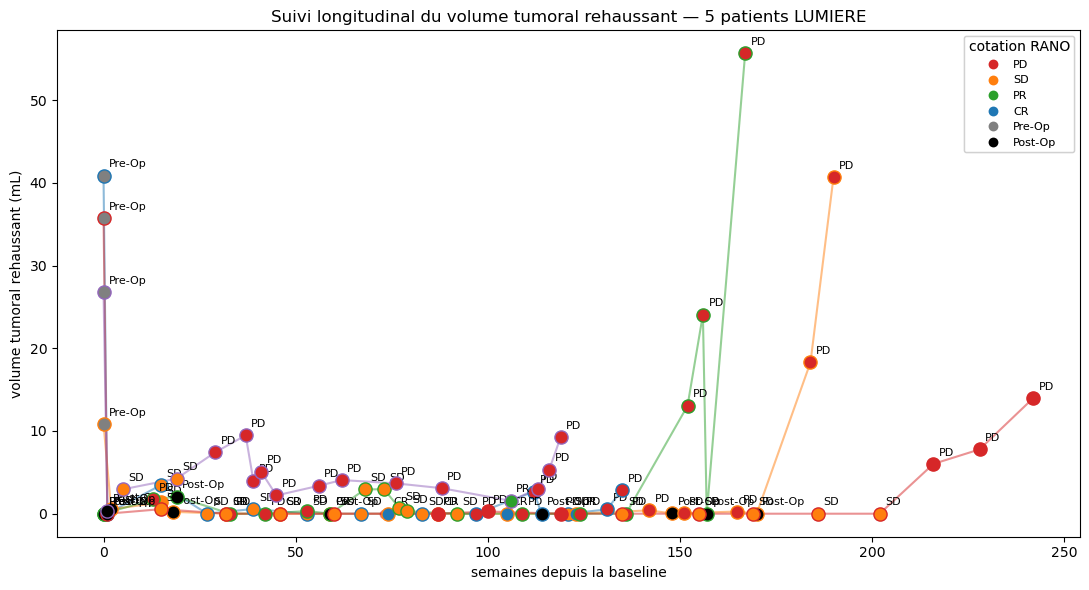

In [6]:
colors = {"PD": "tab:red", "SD": "tab:orange", "PR": "tab:green",
          "CR": "tab:blue", "Pre-Op": "gray", "Post-Op": "black"}

fig, ax = plt.subplots(figsize=(11, 6))
for patient, g in df.groupby("Patient"):
    g = g.sort_values("week")
    line, = ax.plot(g["week"], g["enhancing_mL"], "-o", alpha=0.5, label=patient)
    for _, r in g.iterrows():
        if pd.notna(r["RANO"]):
            ax.scatter(r["week"], r["enhancing_mL"], s=90, zorder=3,
                       color=colors.get(r["RANO"], "gray"),
                       edgecolor=line.get_color())
            ax.annotate(r["RANO"], (r["week"], r["enhancing_mL"]),
                        textcoords="offset points", xytext=(4, 6), fontsize=8)

ax.set_xlabel("semaines depuis la baseline")
ax.set_ylabel("volume tumoral rehaussant (mL)")
ax.set_title("Suivi longitudinal du volume tumoral rehaussant — 5 patients LUMIERE")
ax.legend(title="patient", fontsize=8)
handles = [plt.Line2D([0], [0], marker="o", ls="", color=c, label=k) for k, c in colors.items()]
ax.add_artist(ax.legend(handles=handles, title="cotation RANO", loc="upper right", fontsize=8))
plt.tight_layout()
plt.savefig(os.path.join(DATA, "suivi_5_patients.png"), dpi=110)
plt.show()

## Ce que ca prouve

- on charge bien le **suivi temporel** de 5 patients sans tirer les 32 Go (quelques Mo via range requests),
- on passe du **masque** au **volume tumoral rehaussant** (le coeur de RANO),
- on aligne la trajectoire de volume avec la **cotation RANO experte** du dataset.

Suite logique (projet RANO-Auto) : recalage baseline/suivi propre, regle de decision
volumetrique (+40 % = progression) et comparaison du verdict automatique a la cotation
experte ci-dessus.